In [110]:
from sympy.core.random import sample
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Razumevanje Podataka

### Učitavanje podataka

In [111]:
import pandas as pd
df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")

### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [112]:
df.shape

(124275, 15)

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Resource ID                    124275 non-null  str    
 1   Service Name                   124275 non-null  str    
 2   Usage Quantity                 124275 non-null  float64
 3   Usage Unit                     124275 non-null  str    
 4   Region / Zone                  124275 non-null  str    
 5   CPU Utilization (%)            124275 non-null  float64
 6   Memory Utilization (%)         124275 non-null  float64
 7   Network Inbound Data (Bytes)   124275 non-null  float64
 8   Network Outbound Data (Bytes)  124275 non-null  float64
 9   Usage Start Date               124275 non-null  str    
 10  Usage End Date                 124275 non-null  str    
 11  Cost per Quantity ($)          124275 non-null  float64
 12  Unrounded Cost ($)             124275 non

In [114]:
df.isna().sum().sum()

np.int64(0)

Cilj ovog modela je da uspesno predvidi troskove koriscenja cloud resursa za N nedelja. Konkretno nasa ideja je da uradimo Rolling sumu sa fiksnim klizecim prozorom, koja ce nam omoguciti da sabiramo troskove agregiranih redova po resurs ID-ju i po nedelji za fiksni interval od N nedelja.

Pre nego sto uradimo samu agregaciju, potrebno je da proverimo kvalitet podataka i da li je korektno raditi grupaciju po ova dva atributa

### Provera kvaliteta podataka i prirode promenljivi

Kako bismo uradili agregaciju potrebno je da proverimo da li je pravilno vrsiti grupaciju prema Resource ID-ju i Danu. Postoje i druge kategoricke promenljive po kojima je moguce vrsiti grupaciju, kao sto su Service Name, Usage Unit i Region / Zone

Smatramo da je nasa pocetna grupacija ispravna, jer na GCP-u jedan resurs id se moze odnositi samo na jednu vrstu cloud servisa. Takodje u generalno jedan cloud resurs sa jedinstvenim id-jem moze se nalaziti u jednom Regionu, isto vazi i za zonu dostupnosti, generalno je moguce imati jednu instancu samo u jednoj zoni, tako da cemo se u ovoj analizi predrzavati tog pravila. Usage Unit je kategoricka promenljiva koja je direktno povezana sa vrstom servisa i izbacicemo je iz razmatranja u daljem delu analize

In [115]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


Od numerickih promenljivi cemo na prvi pogled izbaciti kolone Rounded Cost i Total Cost koje zajedno sa promenljivom Unrounded Cost, predstavljaju izlaznu varijablu koju mi predvidjamo. Ove promenljive su izvedene jedna iz druge pa je kolinearnost veoma visoka. Ostavicemo samo kolonu Unrounded Cost.

In [116]:
df.drop(columns=['Usage Unit','Total Cost (INR)','Rounded Cost ($)', 'Resource ID'],inplace=True)

Nakon toga izdvojicemo iz promenljivih tipa datum sledeca vazna obelezja: <br>
Promenljivu week koja omogucava smisleno poredjenje datuma <br>
Promenljivu duration_of_hours koja oznacava trajanje koriscenja resursa <br>

In [117]:
df['Usage Start Date'] = pd.to_datetime(df['Usage Start Date'],errors='raise')
df['Usage End Date'] = pd.to_datetime(df['Usage End Date'],errors='raise')

df['duration_hours'] = (df['Usage End Date'] - df['Usage Start Date']).dt.total_seconds() / 3600
df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)

Nakon toga prikazujemo jos jednom tipove promenljivih

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Service Name                   124275 non-null  str    
 1   Usage Quantity                 124275 non-null  float64
 2   Region / Zone                  124275 non-null  str    
 3   CPU Utilization (%)            124275 non-null  float64
 4   Memory Utilization (%)         124275 non-null  float64
 5   Network Inbound Data (Bytes)   124275 non-null  float64
 6   Network Outbound Data (Bytes)  124275 non-null  float64
 7   Cost per Quantity ($)          124275 non-null  float64
 8   Unrounded Cost ($)             124275 non-null  float64
 9   duration_hours                 124275 non-null  float64
dtypes: float64(8), str(2)
memory usage: 9.5 MB


Takodje cemo izbaciti iz dataset-a, dve numericke promenljive koje logicki jako dobro predvidjaju izlazni trosak resursa a to su cost per quantity i Usage Quantity jer ce model davati jako veliki znacaj ovim atributima, sto nije nas fokus. Nas fokus je da se predvidja buduca potrosnja na osnovu istorijske tako da ce se ovde koristiti samo Usage Quantity kao istorijski podatak o iskoriscenosti

In [119]:
df.drop(columns='Cost per Quantity ($)',inplace=True)

Pre same agregacije izvrsicemo proveru negativnih vrednosti numerickih promenljiva, koje mogu nastati greskom upisa ili iz drugih tehnickih razloga kao sto su pretpostavljamo GCP krediti. U svakom slucaju izbacicemo one redove koje imaju negativne vrednosti

In [120]:
num_cols = ['Usage Quantity','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','duration_hours']

In [121]:
positive_instances = (df[num_cols] >= 0).all(axis=1)
df = df[positive_instances].reset_index(drop=True)

Nakon izbacivanja negativnih opservacija, radimo agregaciju po resursnom ID-ju (instanca cloud servisa) i nedelje. Konkretan razlog zasto ne radimo agregaciju po danima je zato sto dataset ne poseduje dovoljno unosa, da bi moglo kvalitetno predvidjanje da se izvrsi na dnevnom nivou

Agregacija funckionise na sledeci nacin, racunaju se totalne metrike za trosak, kolicinu koriscenja, trajanje i mrezni saobracaj, prosecne metrike za iskoriscenost procesora i memorije. Dok se Service i Region uzimaju od prvog reda u grupi sobzirom da smo pretpostavili da jedan moze biti samo jednog tipa i u jednoj regiji / zoni

Nakon kreiranja agregacije, vrsimo kreiranje kotrljajuce sume, sabirajuci metrike za svaku nedelju najvise num_of_weeks puta. Konkretno se za prozor koristi kalendarski datumi a ne datumi iz dataset-a. Tako da su uracunate rupe u dataset-u

Primer rolling sume za Resurs ID-ja 1

Za samu neuronsku mrezu vise nisu potrebni id resursa i nedelja koja se ne moze pretvoriti u numericki podatak. Sada postoji windows_weeks_count promenljiva koja ce se koristiti kao broj nedelja

## Provera multikolinearnosti

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

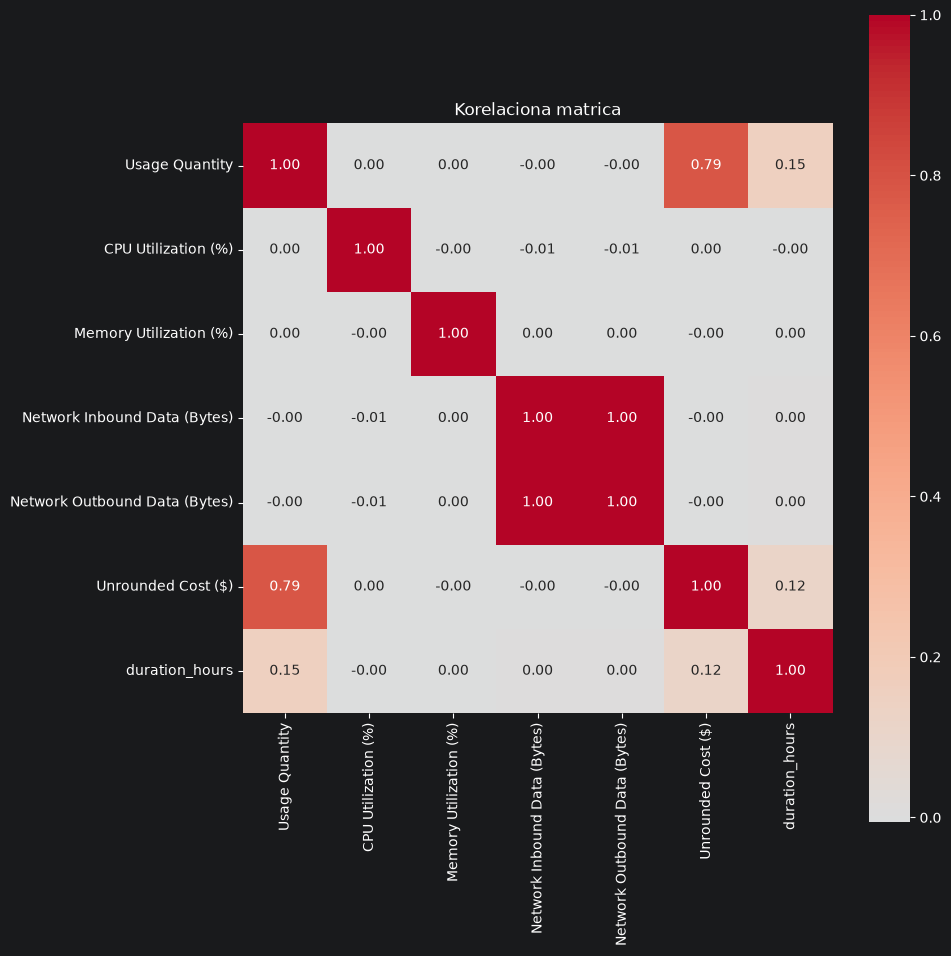

In [123]:
plot_correlation_heatmap(df,num_cols)

In [124]:
df.drop(columns=['Usage Quantity','Network Inbound Data (Bytes)'], inplace=True)
num_cols.remove('Usage Quantity')
num_cols.remove('Network Inbound Data (Bytes)')

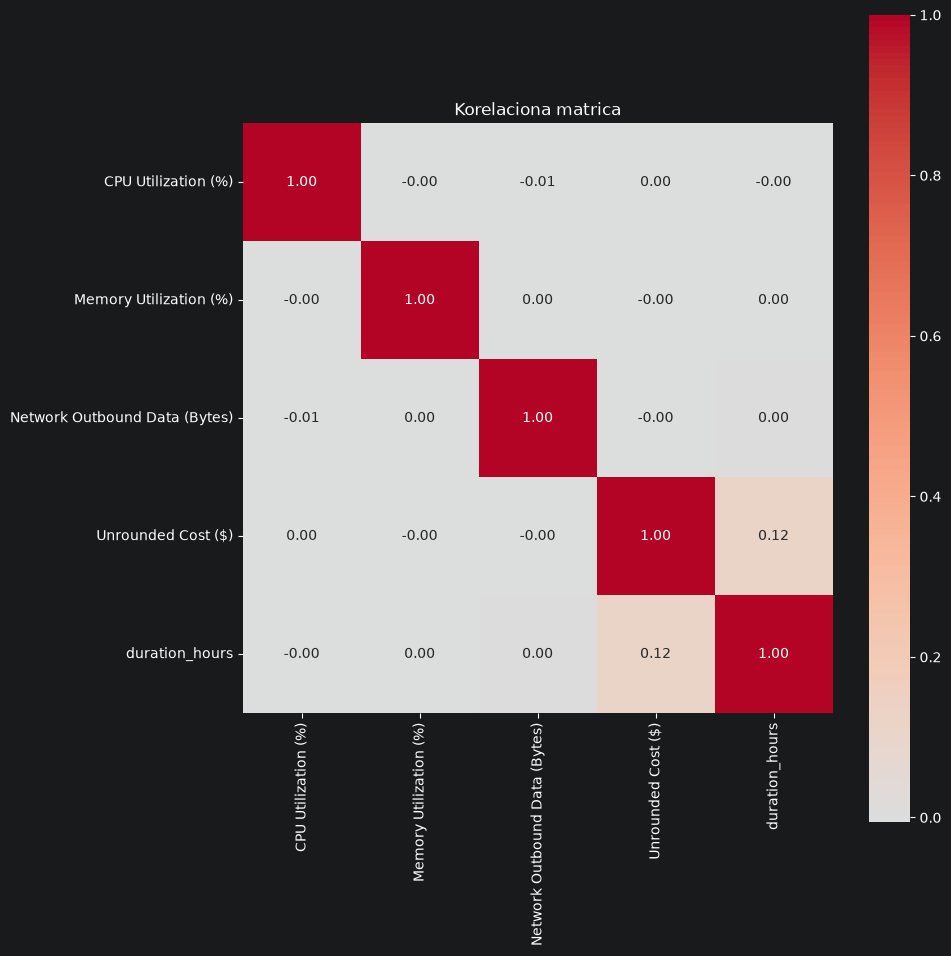

In [125]:
plot_correlation_heatmap(df,num_cols)

### Testiranje simetricnosti raspodela

Kako bismo omogucili skaliranje promenljivi i efikasni backpropagation, potrebno je testirati simetricnost raspodela promenljvi i transformisati promenljive sa asimetricnom raspodelom

In [126]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("broj opservacija")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

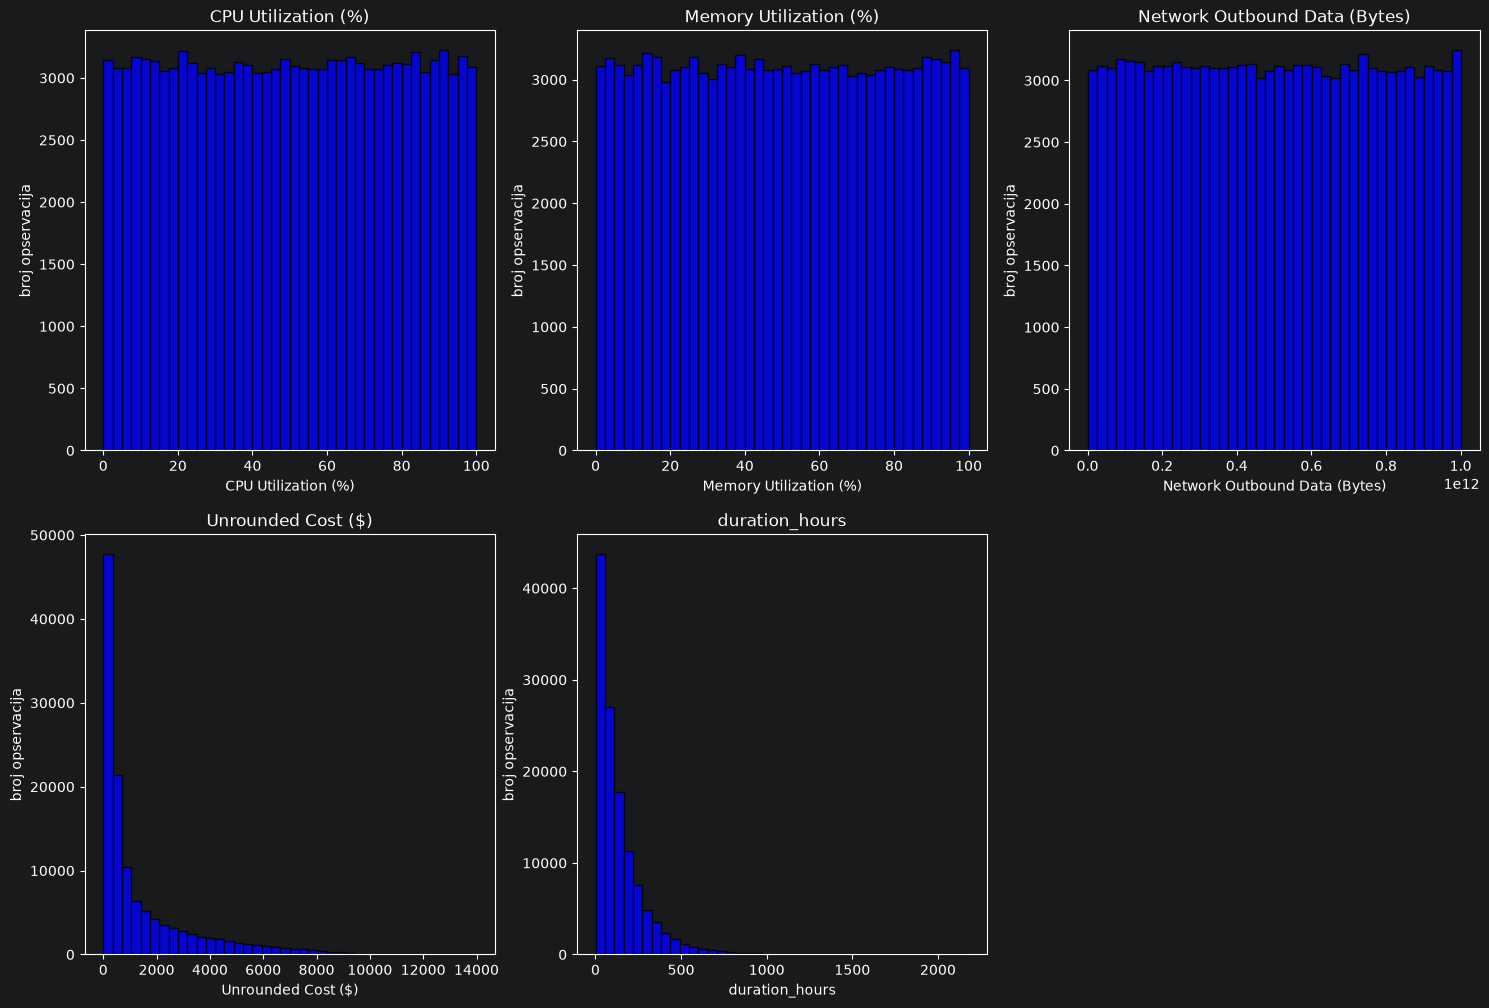

In [127]:
plot_num_cols(df,num_cols)

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da sumarne metrike imaju raspodelu asimetricnu udesno. Primenicemo logaritamsku tranformaciju kako bismo korigovali ove raspodele

In [128]:
from scipy.stats import skew
for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

CPU Utilization (%): skew = -0.004
Memory Utilization (%): skew = 0.002
Network Outbound Data (Bytes): skew = 0.005
Unrounded Cost ($): skew = 1.875
duration_hours: skew = 2.708


In [129]:
df['Unrounded Cost ($)'] = np.log1p(df['Unrounded Cost ($)'])
df['duration_hours'] = np.log1p(df['duration_hours'])

### Graficki prikaz raspodela transformisanih kolona

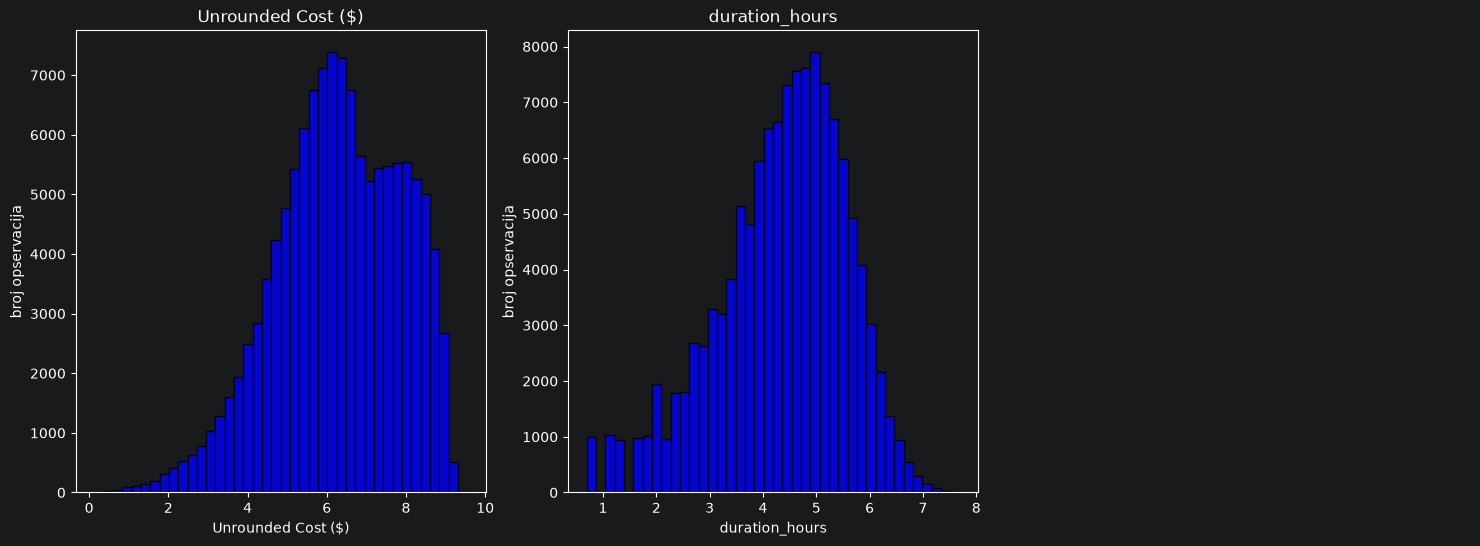

In [130]:
plot_num_cols(df,['Unrounded Cost ($)','duration_hours'])

Sada sumarne skale teze simetricnim raspodelama

In [131]:
for col in ['Unrounded Cost ($)','duration_hours']:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Unrounded Cost ($): skew = -0.394
duration_hours: skew = -0.596


Poslednje sto moramo da uradimo je konvertujemo numericke promenljive service i region u numericke, to cemo postici one-hot encoding-om

In [132]:
def one_hot_encode_col(dataframe, column):
    ohe = pd.get_dummies(dataframe[column], dtype=int)
    df_res = pd.concat([dataframe.drop(columns=column),ohe], axis=1)
    return df_res

In [133]:
df = one_hot_encode_col(df,'Service Name')
df = one_hot_encode_col(df,'Region / Zone')

In [134]:
df.sample(n = 10, random_state = 17)

,CPU Utilization (%),Memory Utilization (%),Network Outbound Data (Bytes),Unrounded Cost ($),duration_hours,App Engine,Artifact Registry,BigQuery,Cloud Armor,Cloud Build,...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
89924,9.17,89.07,1.306690e+11,7.864553,5.541264,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
57738,9.43,11.88,6.157440e+11,5.042909,5.342334,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
62271,40.11,28.23,7.254920e+11,6.861472,5.181784,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
98228,18.21,61.31,5.935249e+10,6.683426,4.543295,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
33495,77.47,62.08,7.896220e+11,2.959359,1.098612,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
850,5.18,37.36,9.005960e+11,5.582257,4.624973,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
25974,60.76,87.86,5.518410e+11,5.694924,6.161207,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
109838,88.95,74.52,6.426880e+11,7.712348,5.398163,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
64138,22.84,14.71,5.757210e+11,6.223537,5.332719,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
76491,69.66,92.95,2.719520e+11,5.721501,4.276666,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CPU Utilization (%)            124275 non-null  float64
 1   Memory Utilization (%)         124275 non-null  float64
 2   Network Outbound Data (Bytes)  124275 non-null  float64
 3   Unrounded Cost ($)             124275 non-null  float64
 4   duration_hours                 124275 non-null  float64
 5   App Engine                     124275 non-null  int64  
 6   Artifact Registry              124275 non-null  int64  
 7   BigQuery                       124275 non-null  int64  
 8   Cloud Armor                    124275 non-null  int64  
 9   Cloud Build                    124275 non-null  int64  
 10  Cloud CDN                      124275 non-null  int64  
 11  Cloud Dataflow                 124275 non-null  int64  
 12  Cloud Dataproc                 124275 non

## Skaliranje podataka i treniranje modela

In [136]:
#TODO: Uraditi StandardScaler nad Svim numerickim podacima osim one hot encoded kolona
#TODO: Pri predikciji iskoristiti eksponencijalnu transformaciju nad promenljivama koje su logaritamski transformisane